In [1]:
import pandas as pd

df = pd.read_csv('../data/house_data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [3]:
df = df.drop('society', axis=1)
df = df.dropna(subset=['location', 'size', 'bath'])
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [4]:
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))
df[['size', 'bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


In [5]:
def is_valid_number(x):
    try:
        float(x)
        return True
    except:
        return False

df[~df['total_sqft'].apply(is_valid_number)].head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk
30,Super built-up Area,19-Dec,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000,4
122,Super built-up Area,18-Mar,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000,4
137,Super built-up Area,19-Mar,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005,2
165,Super built-up Area,18-Dec,Sarjapur,2 BHK,1145 - 1340,2.0,0.0,43.490,2
188,Super built-up Area,Ready To Move,KR Puram,2 BHK,1015 - 1540,2.0,0.0,56.800,2


In [6]:
def convert_sqft(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna(subset=['total_sqft'])
df['total_sqft'].head()

0    1056.0
1    2600.0
2    1440.0
3    1521.0
4    1200.0
Name: total_sqft, dtype: float64

In [7]:
# Step 1: drop columns we don't need anymore
df = df.drop(['size', 'availability'], axis=1)

# Step 2: reduce location categories (too many unique locations = noisy for model)
df['location'] = df['location'].apply(lambda x: x.strip())
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10]
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

# Step 3: remove unrealistic rows (sqft per bedroom too small)
df = df[~(df['total_sqft'] / df['bhk'] < 300)]

# Step 4: create price_per_sqft, remove extreme outliers within each location
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

def remove_pps_outliers(df):
    out = pd.DataFrame()
    for key, sub_df in df.groupby('location'):
        m = sub_df['price_per_sqft'].mean()
        st = sub_df['price_per_sqft'].std()
        reduced = sub_df[(sub_df['price_per_sqft'] > (m - st)) & (sub_df['price_per_sqft'] <= (m + st))]
        out = pd.concat([out, reduced], ignore_index=True)
    return out

df = remove_pps_outliers(df)

df.shape

(10293, 8)

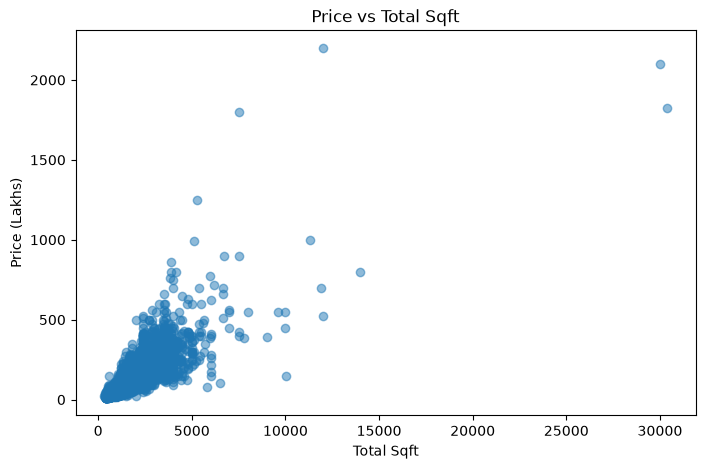

,total_sqft,bath,balcony,price,bhk,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,2850.0,4.0,1.0,428.0,4,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,2.0,194.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3.0,235.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,0.0,130.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2.0,148.0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
import matplotlib.pyplot as plt

# Quick visual check: price vs total_sqft
plt.figure(figsize=(8,5))
plt.scatter(df['total_sqft'], df['price'], alpha=0.5)
plt.xlabel('Total Sqft')
plt.ylabel('Price (Lakhs)')
plt.title('Price vs Total Sqft')
plt.show()

# One-hot encode location (convert text categories into 0/1 columns)
dummies = pd.get_dummies(df['location'], drop_first=True)
df = pd.concat([df, dummies], axis=1)
df = df.drop(['location', 'area_type', 'price_per_sqft'], axis=1)

df.head()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Step 1: Features (X) aur Target (y) alag karo
X = df.drop('price', axis=1)
y = df['price']

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Linear Regression train karo
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Step 4: Random Forest train karo
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Step 5: Compare both models
print("Linear Regression:")
print("R2 Score:", r2_score(y_test, lr_preds))
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))

print("\nRandom Forest:")
print("R2 Score:", r2_score(y_test, rf_preds))
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))

Linear Regression:
R2 Score: 0.7777599217887703
MAE: 19.438330897734424
RMSE: 43.180804750667576

Random Forest:
R2 Score: 0.685273054711671
MAE: 17.82070219023776
RMSE: 51.386200201212766


In [10]:
import joblib

joblib.dump(lr_model, '../models/house_price_model.pkl')
joblib.dump(X.columns.tolist(), '../models/model_columns.pkl')

print("Model saved successfully!")

Model saved successfully!
